# Content Moderation Model Training

Multi-label text classification for detecting harmful content in user-generated text.

**Dataset:** Jigsaw Toxic Comment Classification (via kagglehub)

**Models Compared:** BERT · RoBERTa · DistilBERT

**Labels:** Toxicity · Severe Toxicity · Obscene · Threat · Insult · Identity Hate


In [1]:
!pip install -q transformers torch scikit-learn pandas numpy joblib tqdm datasets
!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121

In [2]:
import pandas as pd
import numpy as np
import torch
import re
import json as json_lib
import joblib
import os
import shutil
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, accuracy_score,
    precision_score, recall_score, f1_score, jaccard_score
)
from matplotlib.patches import FancyArrowPatch
import time

warnings.filterwarnings('ignore')
print('Imports successful!')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f"CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

try:
    x = torch.randn(10, 10).cuda()
    y = x @ x
    print(f"GPU computation: OK")
except Exception as e:
    print(f"GPU computation FAILED: {e}")

Imports successful!
PyTorch: 2.10.0+cu128
Device: cuda
CUDA: 12.8
GPU: Tesla T4
Compute capability: (7, 5)
GPU computation: OK


## 1. Data Loading and Preprocessing

In [3]:
LABEL_SCHEMA = {
    "toxicity": 0,
    "severe_toxicity": 1,
    "obscene": 2,
    "threat": 3,
    "insult": 4,
    "identity_hate": 5,
}
REVERSE_LABEL_SCHEMA = {v: k for k, v in LABEL_SCHEMA.items()}
NUM_LABELS = len(LABEL_SCHEMA)

def load_jigsaw_dataset():
    """Load Jigsaw dataset from HuggingFace — no login required."""
    print("Loading Jigsaw dataset from HuggingFace...")
    dataset = load_dataset(
        "thesofakillers/jigsaw-toxic-comment-classification-challenge",
        split="train"
    )
    df = dataset.to_pandas()

    if 'comment_text' in df.columns:
        df = df.rename(columns={'comment_text': 'text'})

    col_to_schema = {
        'toxic': 'toxicity',
        'severe_toxic': 'severe_toxicity',
        'obscene': 'obscene',
        'threat': 'threat',
        'insult': 'insult',
        'identity_hate': 'identity_hate',
    }
    available_cols = [c for c in col_to_schema if c in df.columns]

    print(f"\nRaw dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nSample (raw, before label encoding):")
    print(df[['text'] + available_cols].head(5).to_string())
    print(f"\nRaw label value counts:")
    for col in available_cols:
        pos = df[col].sum()
        print(f"  {col:<20} 1s: {pos:>6,}  ({pos/len(df)*100:.2f}%)")

    def make_label_vector(row):
        vec = [0.0] * NUM_LABELS
        for col in available_cols:
            if row[col] == 1:
                vec[LABEL_SCHEMA[col_to_schema[col]]] = 1.0
        return vec

    df['labels'] = df[available_cols].apply(make_label_vector, axis=1)
    df['source'] = 'jigsaw'

    print(f"\nAfter label encoding sample rows:")
    print(df[['text', 'labels']].head(5).to_string())
    print(f"\nSample clean vector  : {df['labels'].iloc[0]}")
    flagged = df[df['labels'].apply(lambda x: any(v > 0 for v in x))]
    print(f"Sample flagged vector: {flagged['labels'].iloc[0]}")
    print(f"Sample flagged text  : {flagged['text'].iloc[0][:100]}...")

    return df[['text', 'labels', 'source']].copy()

jigsaw_df = load_jigsaw_dataset()
print(f"\nFinal DataFrame: {len(jigsaw_df):,} samples, {len(jigsaw_df.columns)} columns")
print(jigsaw_df.head(3).to_string())

Loading Jigsaw dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]


Raw dataset shape: (159571, 8)
Columns: ['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample (raw, before label encoding):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 text  toxic  severe_toxic  obscene  threat  insult  identity_hate
0                                                                                                                                             

In [4]:
def print_label_stats(df, name='Dataset'):
    total = len(df)
    has_any = df['labels'].apply(lambda x: any(v > 0 for v in x))
    n_toxic = has_any.sum()
    n_clean = total - n_toxic

    print(f'  {name}')
    print(f'  Total samples : {total:,}')
    print(f'  Clean (no label): {n_clean:,} ({n_clean/total*100:.2f}%)')
    print(f'  Flagged (any label): {n_toxic:,} ({n_toxic/total*100:.2f}%)')
    print(f'  Imbalance ratio: 1 toxic per {n_clean/n_toxic:.1f} clean')
    print(f'  {"─"*53}')
    print(f'  {'Label':<20} {'Count':>8} {'% of total':>12} {'% of flagged':>14}')
    print(f'  {"─"*53}')
    label_counts = {REVERSE_LABEL_SCHEMA[i]: 0 for i in range(NUM_LABELS)}
    for label_vec in df['labels']:
        for i, val in enumerate(label_vec):
            if val == 1.0:
                label_counts[REVERSE_LABEL_SCHEMA[i]] += 1
    for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
        pct_total   = count / total * 100
        pct_flagged = count / n_toxic * 100 if n_toxic > 0 else 0
        print(f'  {label:<20} {count:>8,} {pct_total:>11.2f}% {pct_flagged:>13.2f}%')
    print(f'  {"─"*53}')
    multi = df['labels'].apply(lambda x: sum(v > 0 for v in x))
    print(f'  Avg labels per flagged sample: {multi[multi>0].mean():.2f}')
    print(f'  Samples with 2+ labels: {(multi>=2).sum():,}')
    print(f'  Samples with 3+ labels: {(multi>=3).sum():,}')

print_label_stats(jigsaw_df, 'FULL DATASET (before split)')


  FULL DATASET (before split)
  Total samples : 159,571
  Clean (no label): 143,346 (89.83%)
  Flagged (any label): 16,225 (10.17%)
  Imbalance ratio: 1 toxic per 8.8 clean
  ─────────────────────────────────────────────────────
  Label                   Count   % of total   % of flagged
  ─────────────────────────────────────────────────────
  toxicity               15,294        9.58%         94.26%
  obscene                 8,449        5.29%         52.07%
  insult                  7,877        4.94%         48.55%
  severe_toxicity         1,595        1.00%          9.83%
  identity_hate           1,405        0.88%          8.66%
  threat                    478        0.30%          2.95%
  ─────────────────────────────────────────────────────
  Avg labels per flagged sample: 2.16
  Samples with 2+ labels: 9,865
  Samples with 3+ labels: 6,385


In [5]:
TARGET_SIZE = 30000
TOXIC_RATIO = 0.5

label_cols = list(LABEL_SCHEMA.keys())
jigsaw_df['has_any_label'] = jigsaw_df['labels'].apply(lambda x: any(v > 0 for v in x))

toxic_df = jigsaw_df[jigsaw_df['has_any_label']].copy()
clean_df = jigsaw_df[~jigsaw_df['has_any_label']].copy()

print(f"BEFORE subsampling:")
print(f"  Toxic rows: {len(toxic_df):>7,}  ({len(toxic_df)/len(jigsaw_df)*100:5.2f}%)")
print(f"  Clean rows: {len(clean_df):>7,}  ({len(clean_df)/len(jigsaw_df)*100:5.2f}%)")
print(f"  Total     : {len(jigsaw_df):>7,}")

n_toxic_target = min(len(toxic_df), int(TARGET_SIZE * TOXIC_RATIO))
n_clean_target = TARGET_SIZE - n_toxic_target

rare_labels = ['threat', 'severe_toxicity', 'identity_hate']
rare_idx    = [LABEL_SCHEMA[l] for l in rare_labels]

def rarity_score(label_list):
    return sum(label_list[i] for i in rare_idx)

toxic_df['rarity_score'] = toxic_df['labels'].apply(rarity_score)
toxic_df = toxic_df.sort_values('rarity_score', ascending=False)

rare_rows   = toxic_df[toxic_df['rarity_score'] > 0]
common_rows = toxic_df[toxic_df['rarity_score'] == 0]

if len(rare_rows) >= n_toxic_target:
    sampled_toxic = rare_rows.head(n_toxic_target)
    print(f"\n  Note: rare-label rows alone ({len(rare_rows):,}) exceed target — using top {n_toxic_target:,}")
else:
    n_common_needed = n_toxic_target - len(rare_rows)
    sampled_common  = common_rows.sample(n=min(n_common_needed, len(common_rows)), random_state=42)
    sampled_toxic   = pd.concat([rare_rows, sampled_common])
    print(f"\n  Kept ALL {len(rare_rows):,} rare-label rows + {len(sampled_common):,} common toxic rows")

sampled_clean = clean_df.sample(n=n_clean_target, random_state=42)
jigsaw_df = pd.concat([sampled_toxic, sampled_clean]).sample(frac=1, random_state=42).reset_index(drop=True)
jigsaw_df = jigsaw_df.drop(columns=['has_any_label', 'rarity_score'], errors='ignore')

print(f"\nAFTER subsampling:")
print(f"  Toxic rows: {n_toxic_target:>7,}  ({n_toxic_target/TARGET_SIZE*100:5.2f}%)  ← cut {len(toxic_df) - n_toxic_target:,}")
print(f"  Clean rows: {n_clean_target:>7,}  ({n_clean_target/TARGET_SIZE*100:5.2f}%)  ← cut {len(clean_df) - n_clean_target:,}")
print(f"  Total     : {len(jigsaw_df):>7,}")

print(f"\nLabel distribution after subsampling:")
for col_name, col_idx in LABEL_SCHEMA.items():
    count = jigsaw_df['labels'].apply(lambda x: x[col_idx]).sum()
    pct = count / len(jigsaw_df) * 100
    print(f"  {col_name:<20} {count:>5,}  ({pct:5.2f}%)")


BEFORE subsampling:
  Toxic rows:  16,225  (10.17%)
  Clean rows: 143,346  (89.83%)
  Total     : 159,571

  Kept ALL 2,987 rare-label rows + 12,013 common toxic rows

AFTER subsampling:
  Toxic rows:  15,000  (50.00%)  ← cut 1,225
  Clean rows:  15,000  (50.00%)  ← cut 128,346
  Total     :  30,000

Label distribution after subsampling:
  toxicity             14,141.0  (47.14%)
  severe_toxicity      1,595.0  ( 5.32%)
  obscene              7,872.0  (26.24%)
  threat               478.0  ( 1.59%)
  insult               7,385.0  (24.62%)
  identity_hate        1,405.0  ( 4.68%)


In [6]:
jigsaw_df['has_toxic'] = jigsaw_df['labels'].apply(lambda x: int(any(v > 0 for v in x)))

train_val, test_df = train_test_split(
    jigsaw_df, test_size=0.15, random_state=42,
    stratify=jigsaw_df['has_toxic']
)
train_df, val_df = train_test_split(
    train_val, test_size=0.15/0.85, random_state=42,
    stratify=train_val['has_toxic']
)

for _df in [jigsaw_df, train_df, val_df, test_df]:
    _df.drop(columns=['has_toxic'], inplace=True, errors='ignore')

print(f'Split sizes:')
print(f'  Train : {len(train_df):>6,} ({len(train_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  Val   : {len(val_df):>6,} ({len(val_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  Test  : {len(test_df):>6,} ({len(test_df)/len(jigsaw_df)*100:.1f}%)')

print_label_stats(train_df, 'TRAIN SPLIT')
print_label_stats(val_df,   'VAL SPLIT')
print_label_stats(test_df,  'TEST SPLIT')

print('\nToxic ratio consistency check (should be ~equal):')
for name, df in [('Full', jigsaw_df), ('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    ratio = df['labels'].apply(lambda x: any(v > 0 for v in x)).mean()
    print(f'  {name:<6}: {ratio:.4f} ({ratio*100:.2f}% toxic)')

Split sizes:
  Train : 21,000 (70.0%)
  Val   :  4,500 (15.0%)
  Test  :  4,500 (15.0%)
  TRAIN SPLIT
  Total samples : 21,000
  Clean (no label): 10,500 (50.00%)
  Flagged (any label): 10,500 (50.00%)
  Imbalance ratio: 1 toxic per 1.0 clean
  ─────────────────────────────────────────────────────
  Label                   Count   % of total   % of flagged
  ─────────────────────────────────────────────────────
  toxicity                9,903       47.16%         94.31%
  obscene                 5,494       26.16%         52.32%
  insult                  5,173       24.63%         49.27%
  severe_toxicity         1,104        5.26%         10.51%
  identity_hate             999        4.76%          9.51%
  threat                    328        1.56%          3.12%
  ─────────────────────────────────────────────────────
  Avg labels per flagged sample: 2.19
  Samples with 2+ labels: 6,449
  Samples with 3+ labels: 4,206
  VAL SPLIT
  Total samples : 4,500
  Clean (no label): 2,250 (50.0

## 2. Text Preprocessing & Tokenization

In [7]:
class TextPreprocessor:
    """Basic text cleaning — remove URLs, HTML, mentions, hashtags."""
    @staticmethod
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^\w\s.,!?-]', '', text)
        return re.sub(r'\s+', ' ', text).strip()


def make_hf_dataset(df, tokenizer, max_length=128):
    """
    Convert a pandas DataFrame to a HuggingFace Dataset and tokenize it.
    max_length=128 is a good balance between speed and context for short texts.
    """
    preprocessor = TextPreprocessor()
    cleaned_texts = [preprocessor.clean_text(t) for t in df['text'].tolist()]

    hf_ds = Dataset.from_dict({
        'text':   cleaned_texts,
        'labels': df['labels'].tolist(),
    })

    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=max_length)

    hf_ds = hf_ds.map(tokenize, batched=True)
    hf_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return hf_ds

preprocessor = TextPreprocessor()
sample = "This is TOXIC!!! Visit www.spam.com @troll #hate"
print(f"Original : {sample}")
print(f"Cleaned  : {preprocessor.clean_text(sample)}")


Original : This is TOXIC!!! Visit www.spam.com @troll #hate
Cleaned  : This is TOXIC!!! Visit


## 3. Model Training with HuggingFace Trainer API

We use the `Trainer` API which handles the training loop, optimizer scheduling,
evaluation, and checkpointing automatically — following the best practices from the
original BERT/RoBERTa papers.

Key setup for multi-label classification:
- `problem_type='multi_label_classification'` → model uses **Binary Cross-Entropy** loss per label
- `compute_metrics` uses **sigmoid + threshold 0.5** per label (not argmax)
- Labels are **multi-hot float vectors** e.g. `[1, 0, 1, 0, 1, 0]`


In [8]:
def compute_metrics(eval_pred):
    """
    Multi-label metrics for Trainer API.
    Uses sigmoid + 0.5 threshold per label — NOT argmax.
    argmax would assume single-label (only one class wins),
    which is wrong here since a text can be toxic AND obscene AND insulting.

    Metrics explained for defense:
      - f1 (macro)     : avg F1 across all 6 labels — penalizes poor rare-label performance
      - precision      : of predictions flagged, what fraction are correct
      - recall         : of actual toxic samples, what fraction we catch
      - jaccard (micro): set overlap between predicted and true labels
      - hamming_loss   : fraction of label predictions that are wrong (lower = better)
      - accuracy       : per-label accuracy averaged across labels (lenient — credit per correct label)
      - subset_accuracy: ALL 6 labels must match exactly (strict multi-label accuracy)
    """
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)
    labels = labels.astype(int)

    # Per-label accuracy: average accuracy across each of the 6 label columns
    per_label_acc = (preds == labels).mean(axis=0).mean()

    # Subset accuracy: exact match across ALL 6 labels per row (strict)
    subset_acc = (preds == labels).all(axis=1).mean()

    return {
        'f1':              f1_score(labels, preds, average='macro', zero_division=0),
        'precision':       precision_score(labels, preds, average='macro', zero_division=0),
        'recall':          recall_score(labels, preds, average='macro', zero_division=0),
        'jaccard':         jaccard_score(labels, preds, average='micro', zero_division=0),
        'hamming_loss':    hamming_loss(labels, preds),
        'accuracy':        float(per_label_acc),
        'subset_accuracy': float(subset_acc),
    }


def compute_per_label_metrics(eval_pred):
    """Compute F1 per label — used for the heatmap comparison."""
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)
    labels = labels.astype(int)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {REVERSE_LABEL_SCHEMA[i]: round(float(f1_per[i]), 4) for i in range(NUM_LABELS)}


def train_model(model_name, train_df, val_df, test_df, epochs=3, batch_size=16, learning_rate=2e-5):
    """
    Fine-tune a pretrained transformer for multi-label text classification.

    Args:
        model_name    : HuggingFace model ID
        train_df      : training split DataFrame
        val_df        : validation split DataFrame
        test_df       : test split DataFrame
        epochs        : number of fine-tuning epochs
        batch_size    : samples per gradient update
        learning_rate : AdamW learning rate

    Returns:
        dict with trainer, tokenizer, test_metrics, per_label_metrics, training_history
    """
    print(f"\n{'='*60}\nModel: {model_name}\n{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("Tokenizing datasets...")
    train_ds = make_hf_dataset(train_df, tokenizer)
    val_ds   = make_hf_dataset(val_df, tokenizer)
    test_ds  = make_hf_dataset(test_df, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        problem_type='multi_label_classification',
    )

    safe_name = model_name.replace('/', '-')
    training_args = TrainingArguments(
        output_dir=f'./results/{safe_name}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        logging_dir=f'./logs/{safe_name}',
        logging_steps=100,
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    history = {}
    for log in trainer.state.log_history:
        if 'eval_f1' in log:
            epoch = int(log['epoch'])
            history[epoch] = {
                'eval_f1':           round(log.get('eval_f1', 0), 4),
                'eval_precision':    round(log.get('eval_precision', 0), 4),
                'eval_recall':       round(log.get('eval_recall', 0), 4),
                'eval_hamming_loss': round(log.get('eval_hamming_loss', 0), 4),
                'eval_loss':         round(log.get('eval_loss', 0), 4),
            }
        elif 'loss' in log and 'eval_f1' not in log:
            step = log['step']
            history.setdefault(f'step_{step}', {'train_loss': round(log['loss'], 4)})

    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_results = trainer.predict(test_ds)
    test_metrics = compute_metrics((test_results.predictions, test_results.label_ids))
    per_label    = compute_per_label_metrics((test_results.predictions, test_results.label_ids))
    print(f"Test metrics: {', '.join(f'{k}={v:.4f}' for k, v in test_metrics.items())}")

    return {
        'trainer':          trainer,
        'tokenizer':        tokenizer,
        'test_metrics':     test_metrics,
        'per_label_metrics': per_label,
        'training_history': history,
    }

print("Trainer setup complete.")


Trainer setup complete.


In [9]:
bert_result = train_model(
    'bert-base-uncased', train_df, val_df, test_df,
    epochs=3, batch_size=16, learning_rate=2e-5
)


Model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating on test set...


Test metrics: f1=0.7151, precision=0.7070, recall=0.7388, jaccard=0.7176, hamming_loss=0.0636, accuracy=0.9364, subset_accuracy=0.7036


In [10]:
roberta_result = train_model(
    'roberta-base', train_df, val_df, test_df,
    epochs=3, batch_size=16, learning_rate=2e-5
)


Model: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Evaluating on test set...


Test metrics: f1=0.7143, precision=0.6993, recall=0.7323, jaccard=0.7196, hamming_loss=0.0624, accuracy=0.9376, subset_accuracy=0.7131


In [11]:
distilbert_result = train_model(
    'distilbert-base-uncased', train_df, val_df, test_df,
    epochs=3, batch_size=32, learning_rate=2e-5
)


Model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating on test set...


Test metrics: f1=0.5867, precision=0.8081, recall=0.5531, jaccard=0.7106, hamming_loss=0.0617, accuracy=0.9383, subset_accuracy=0.7113


## 4. Model Comparison


MODEL COMPARISON ON TEST SET
     Model       f1  precision   recall  jaccard  hamming_loss  accuracy  subset_accuracy
      BERT 0.715099   0.706979 0.738816 0.717624      0.063556  0.936444         0.703556
   RoBERTa 0.714329   0.699296 0.732294 0.719614      0.062370  0.937630         0.713111
DistilBERT 0.586666   0.808102 0.553111 0.710563      0.061704  0.938296         0.711333

Metric guide for defense:
  f1, precision, recall : averaged across all 6 labels (macro)
  jaccard               : how much predicted/true label sets overlap
  hamming_loss          : fraction of WRONG label predictions (lower = better)
  accuracy              : per-label accuracy averaged across labels (lenient)
  subset_accuracy       : ALL 6 labels exact match per row (very strict)


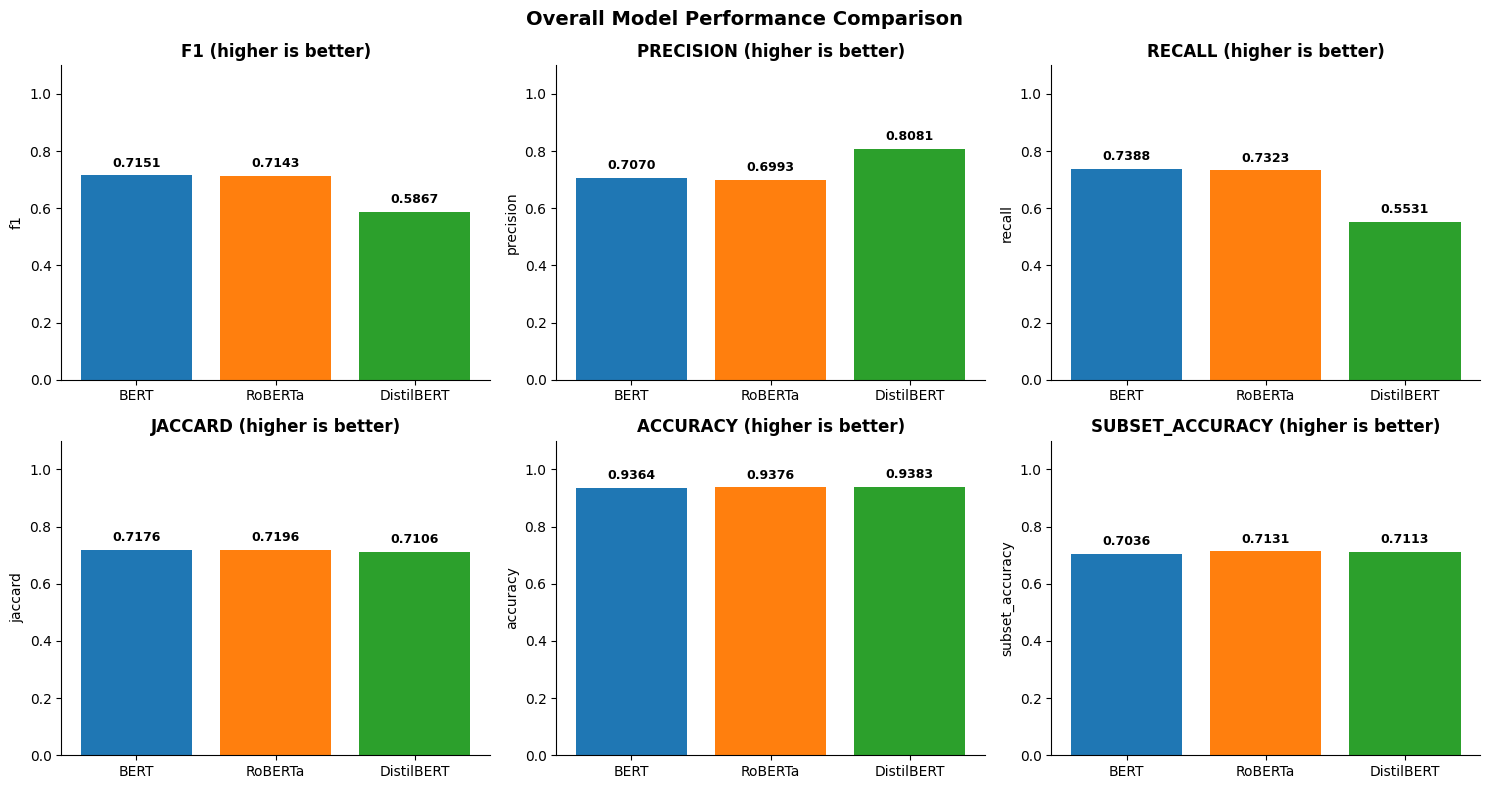

Saved: comparison_overall_metrics.png


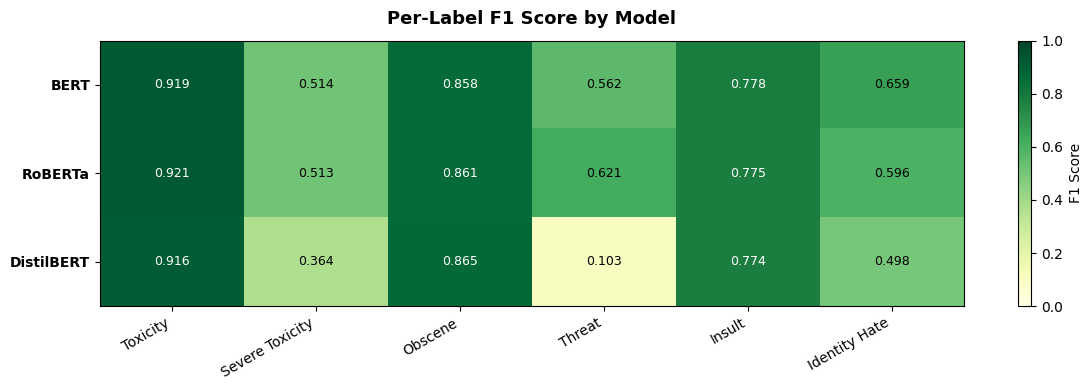

Saved: comparison_per_label_heatmap.png


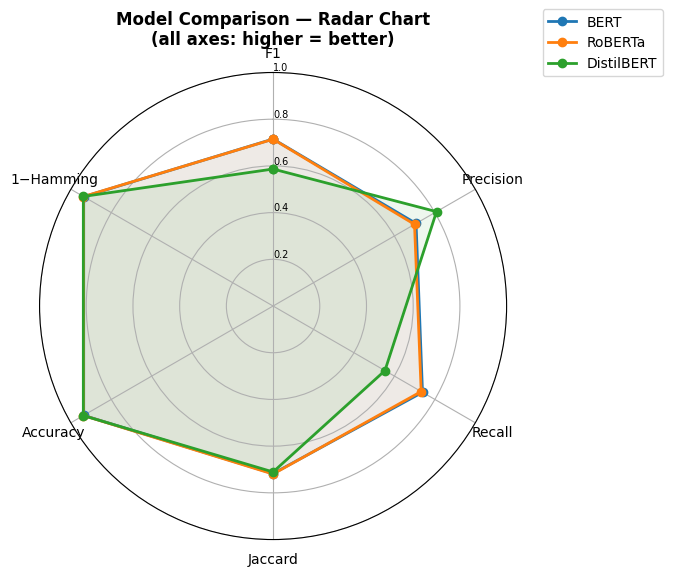

Saved: comparison_radar.png


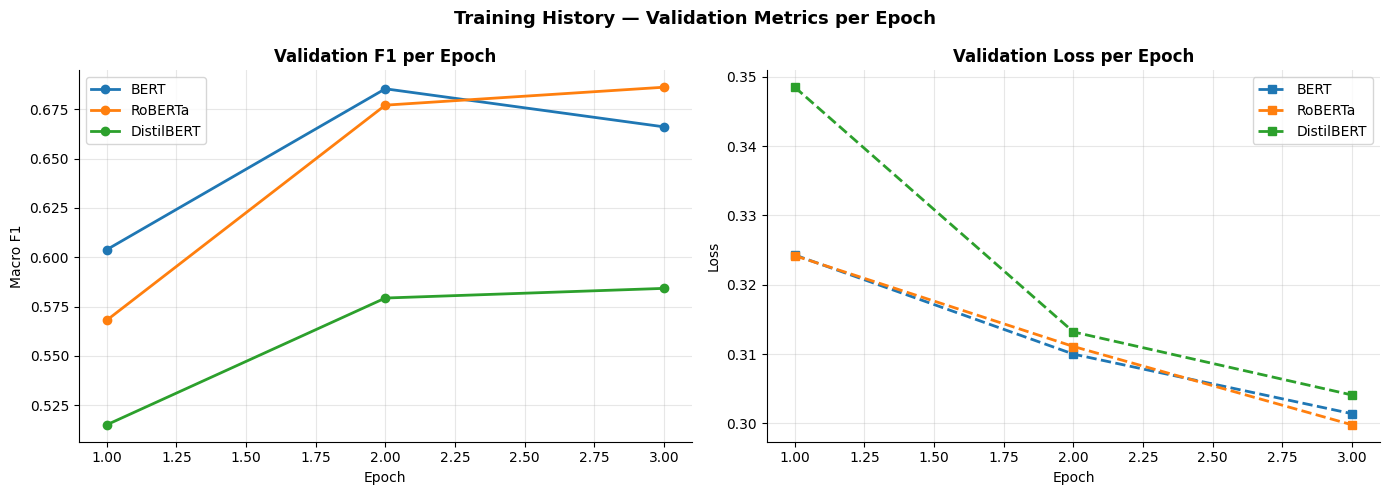

Saved: comparison_training_history.png

BEST MODEL: BERT  (F1 = 0.7151)
  ▲  f1                  : 0.7151
  ▲  precision           : 0.7070
  ▲  recall              : 0.7388
  ▲  jaccard             : 0.7176
  ▼  hamming_loss        : 0.0636
  ▲  accuracy            : 0.9364
  ▲  subset_accuracy     : 0.7036


In [12]:
results = {
    'BERT':       bert_result['test_metrics'],
    'RoBERTa':    roberta_result['test_metrics'],
    'DistilBERT': distilbert_result['test_metrics'],
}
per_label_results = {
    'BERT':       bert_result['per_label_metrics'],
    'RoBERTa':    roberta_result['per_label_metrics'],
    'DistilBERT': distilbert_result['per_label_metrics'],
}

comparison_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('\n' + '='*90 + '\nMODEL COMPARISON ON TEST SET\n' + '='*90)
print(comparison_df.to_string(index=False))

print('\nMetric guide for defense:')
print('  f1, precision, recall : averaged across all 6 labels (macro)')
print('  jaccard               : how much predicted/true label sets overlap')
print('  hamming_loss          : fraction of WRONG label predictions (lower = better)')
print('  accuracy              : per-label accuracy averaged across labels (lenient)')
print('  subset_accuracy       : ALL 6 labels exact match per row (very strict)')

metrics_to_plot = ['f1', 'precision', 'recall', 'jaccard', 'accuracy', 'subset_accuracy']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Overall Model Performance Comparison', fontsize=14, fontweight='bold')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
models = list(results.keys())
for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = [results[m][metric] for m in models]
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(f'{metric.upper()} (higher is better)', fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.set_ylabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('./comparison_overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_overall_metrics.png")

labels_order = list(LABEL_SCHEMA.keys())
heatmap_data = np.array([[per_label_results[m][lbl] for lbl in labels_order] for m in models])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_order)))
ax.set_xticklabels([l.replace('_', ' ').title() for l in labels_order], rotation=30, ha='right')
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontweight='bold')
for i in range(len(models)):
    for j in range(len(labels_order)):
        ax.text(j, i, f'{heatmap_data[i, j]:.3f}', ha='center', va='center',
                fontsize=9, color='black' if heatmap_data[i, j] < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Label F1 Score by Model', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('./comparison_per_label_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_per_label_heatmap.png")

radar_metrics_display = ['F1', 'Precision', 'Recall', 'Jaccard', 'Accuracy', '1−Hamming']

N = len(radar_metrics_display)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
plt.xticks(angles[:-1], radar_metrics_display, size=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax.set_ylim(0, 1)

radar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for model, color in zip(models, radar_colors):
    vals_radar = [
        results[model]['f1'],
        results[model]['precision'],
        results[model]['recall'],
        results[model]['jaccard'],
        results[model]['accuracy'],
        1 - results[model]['hamming_loss'],
    ]
    vals_radar += vals_radar[:1]
    ax.plot(angles, vals_radar, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals_radar, alpha=0.08, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Model Comparison — Radar Chart\n(all axes: higher = better)',
             size=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_radar.png")

histories = {
    'BERT':       bert_result['training_history'],
    'RoBERTa':    roberta_result['training_history'],
    'DistilBERT': distilbert_result['training_history'],
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Validation Metrics per Epoch', fontsize=13, fontweight='bold')
history_colors = {'BERT': '#1f77b4', 'RoBERTa': '#ff7f0e', 'DistilBERT': '#2ca02c'}

for model_name, hist in histories.items():
    epoch_keys = sorted([k for k in hist if isinstance(k, int)])
    if not epoch_keys:
        continue
    epochs_x   = epoch_keys
    f1_vals    = [hist[e]['eval_f1'] for e in epoch_keys]
    loss_vals  = [hist[e]['eval_loss'] for e in epoch_keys]
    color = history_colors[model_name]
    axes[0].plot(epochs_x, f1_vals, 'o-', label=model_name, color=color, linewidth=2)
    axes[1].plot(epochs_x, loss_vals, 's--', label=model_name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation F1 per Epoch', 'Validation Loss per Epoch'],
    ['Macro F1', 'Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./comparison_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_training_history.png")

best_model = max(results, key=lambda m: results[m]['f1'])
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model}  (F1 = {results[best_model]['f1']:.4f})")
print(f"{'='*60}")
for metric, val in results[best_model].items():
    arrow = '▼' if metric == 'hamming_loss' else '▲'
    print(f"  {arrow}  {metric:<20}: {val:.4f}")

## 5. Save Best Model

In [13]:
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

all_results = {
    'bert':       (bert_result,      'bert-base-uncased'),
    'roberta':    (roberta_result,    'roberta-base'),
    'distilbert': (distilbert_result, 'distilbert-base-uncased'),
}

model_folder_map = {
    'bert':       'bert',
    'roberta':    'roberta',
    'distilbert': 'distilbert',
}

for model_type, (result, model_name) in all_results.items():
    folder_name = model_folder_map[model_type]
    save_path   = os.path.join(models_dir, folder_name)
    os.makedirs(save_path, exist_ok=True)

    result['trainer'].save_model(save_path)
    result['tokenizer'].save_pretrained(save_path)

    metrics_out = {
        'model_name':         model_name,
        'model_type':         model_type,
        'folder':             folder_name,
        'num_labels':         NUM_LABELS,
        'label_schema':       LABEL_SCHEMA,
        'test_metrics':       result['test_metrics'],
        'per_label_f1':       result['per_label_metrics'],
        'training_history':   {str(k): v for k, v in result['training_history'].items()},
    }
    with open(os.path.join(save_path, 'metrics.json'), 'w') as f:
        json_lib.dump(metrics_out, f, indent=2)

    joblib.dump({
        'model_name':     model_name,
        'model_type':     model_type,
        'num_labels':     NUM_LABELS,
        'test_metrics':   result['test_metrics'],
        'label_schema':   LABEL_SCHEMA,
        'reverse_schema': {str(k): v for k, v in REVERSE_LABEL_SCHEMA.items()},
    }, os.path.join(save_path, 'config.pkl'))

    with open(os.path.join(save_path, 'model_summary.txt'), 'w') as f:
        f.write(f"Content Moderation Model — {model_name}\n")
        f.write("="*60 + "\n\n")
        f.write(f"Folder    : {folder_name}\n")
        f.write(f"HF ID     : {model_name}\n")
        f.write(f"Num labels: {NUM_LABELS}\n")
        f.write(f"Labels    : {list(LABEL_SCHEMA.keys())}\n\n")
        f.write("Test Metrics:\n")
        for k, v in result['test_metrics'].items():
            f.write(f"  {k:<20}: {v:.4f}\n")
        f.write("\nPer-Label F1:\n")
        for lbl, v in result['per_label_metrics'].items():
            f.write(f"  {lbl:<20}: {v:.4f}\n")

    print(f"Saved: {folder_name}/ (weights + metrics.json + config.pkl + model_summary.txt)")

viz_files = [
    'comparison_overall_metrics.png',
    'comparison_per_label_heatmap.png',
    'comparison_radar.png',
    'comparison_training_history.png',
]
for viz in viz_files:
    if os.path.exists(viz):
        shutil.copy(viz, os.path.join(models_dir, viz))
        print(f"Copied visualization: {viz}")

comparison_out = {}
for model_type, (result, model_name) in all_results.items():
    comparison_out[model_folder_map[model_type]] = {
        'model_name':       model_name,
        'test_metrics':     result['test_metrics'],
        'per_label_f1':     result['per_label_metrics'],
    }
with open(os.path.join(models_dir, 'comparison_results.json'), 'w') as f:
    json_lib.dump(comparison_out, f, indent=2)
print("Saved: comparison_results.json")

best_type = max(all_results, key=lambda k: all_results[k][0]['test_metrics']['f1'])
best_f1   = all_results[best_type][0]['test_metrics']['f1']
print(f"\nBest model: {best_type.upper()} (F1={best_f1:.4f}) → folder: models/{model_folder_map[best_type]}/")

print("\nmodels/ structure:")
for root, dirs, files in os.walk(models_dir):
    level = root.replace(models_dir, '').count(os.sep)
    indent = '  ' * level
    folder_label = os.path.basename(root)
    print(f"{indent}{folder_label}/")
    if level < 2:
        subindent = '  ' * (level + 1)
        for fname in sorted(files):
            fsize = os.path.getsize(os.path.join(root, fname))
            size_label = f"{fsize/1024:.1f} KB" if fsize < 1_048_576 else f"{fsize/1048576:.1f} MB"
            print(f"{subindent}{fname}  [{size_label}]")

zip_path = './models_export'
if os.path.exists(zip_path + '.zip'):
    os.remove(zip_path + '.zip')
shutil.make_archive(zip_path, 'zip', '.', 'models')
zip_size = os.path.getsize(zip_path + '.zip') / 1048576
print(f"\nZipped: models_export.zip  ({zip_size:.1f} MB)")
print("Download models_export.zip to get all model weights, configs, metrics, and visualizations.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: bert/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: roberta/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: distilbert/ (weights + metrics.json + config.pkl + model_summary.txt)
Copied visualization: comparison_overall_metrics.png
Copied visualization: comparison_per_label_heatmap.png
Copied visualization: comparison_radar.png
Copied visualization: comparison_training_history.png
Saved: comparison_results.json

Best model: BERT (F1=0.7151) → folder: models/bert/

models/ structure:
models/
  comparison_overall_metrics.png  [107.6 KB]
  comparison_per_label_heatmap.png  [73.3 KB]
  comparison_radar.png  [147.2 KB]
  comparison_results.json  [1.6 KB]
  comparison_training_history.png  [124.9 KB]
  bert/
    config.json  [1.1 KB]
    config.pkl  [0.5 KB]
    metrics.json  [2.2 KB]
    model.safetensors  [417.7 MB]
    model_summary.txt  [0.7 KB]
    tokenizer.json  [695.0 KB]
    tokenizer_config.json  [0.3 KB]
    training_args.bin  [5.1 KB]
  distilbert/
    config.json  [0.9 KB]
    config.pkl  [0.5 KB]
    metrics.json  [1.7 KB]
    model.safetensors  [255.4 MB]
    model_summary.txt

## 6. Test Inference

INFERENCE TIMING (10 runs × 5 samples per model)

 LOADING MODEL: BERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
  Scores:
    toxicity             0.0079  
    severe_toxicity      0.0036  
    obscene              0.0046  
    threat               0.0043  
    insult               0.0045  
    identity_hate        0.0042  

  [FLAGGED] You are so stupid and worthless!
  Labels     : ['toxicity', 'insult']
  Risk score : 0.9853
  Scores:
    toxicity             0.9853  ███████████████████
    severe_toxicity      0.0516  █
    obscene              0.4800  █████████
    threat               0.0223  
    insult               0.9325  ██████████████████
    identity_hate        0.0337  

  [FLAGGED] I hate people from that country.
  Labels     : ['toxicity']
  Risk score : 0.9153
  Scores:
    toxicity             0.9153  ██████████████████
    severe_toxicity      0.0095  
    obscene              0.0489  
    threat               0.0175  
    insult               0.1171  ██
    identity_hate        0.1141  ██

  [FLAGGED] I am going to hurt y

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
  Scores:
    toxicity             0.0056  
    severe_toxicity      0.0036  
    obscene              0.0043  
    threat               0.0040  
    insult               0.0038  
    identity_hate        0.0038  

  [FLAGGED] You are so stupid and worthless!
  Labels     : ['toxicity', 'obscene', 'insult']
  Risk score : 0.9877
  Scores:
    toxicity             0.9877  ███████████████████
    severe_toxicity      0.0789  █
    obscene              0.7917  ███████████████
    threat               0.0149  
    insult               0.9697  ███████████████████
    identity_hate        0.0341  

  [FLAGGED] I hate people from that country.
  Labels     : ['toxicity']
  Risk score : 0.9378
  Scores:
    toxicity             0.9378  ██████████████████
    severe_toxicity      0.0078  
    obscene              0.0196  
    threat               0.0400  
    insult               0.0706  █
    identity_hate        0.1021  ██

  [FLAGGED] I a

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  [CLEAN] This is a great product! Highly recommend.
  Scores:
    toxicity             0.0090  
    severe_toxicity      0.0029  
    obscene              0.0054  
    threat               0.0041  
    insult               0.0042  
    identity_hate        0.0039  

  [FLAGGED] You are so stupid and worthless!
  Labels     : ['toxicity', 'insult']
  Risk score : 0.9745
  Scores:
    toxicity             0.9745  ███████████████████
    severe_toxicity      0.0420  
    obscene              0.4233  ████████
    threat               0.0397  
    insult               0.8485  ████████████████
    identity_hate        0.0392  

  [FLAGGED] I hate people from that country.
  Labels     : ['toxicity']
  Risk score : 0.8326
  Scores:
    toxicity             0.8326  ████████████████
    severe_toxicity      0.0058  
    obscene              0.0221  
    threat               0.0230  
    insult               0.0643  █
    identity_hate        0.0243  

  [FLAGGED] I am going to hurt you, watch

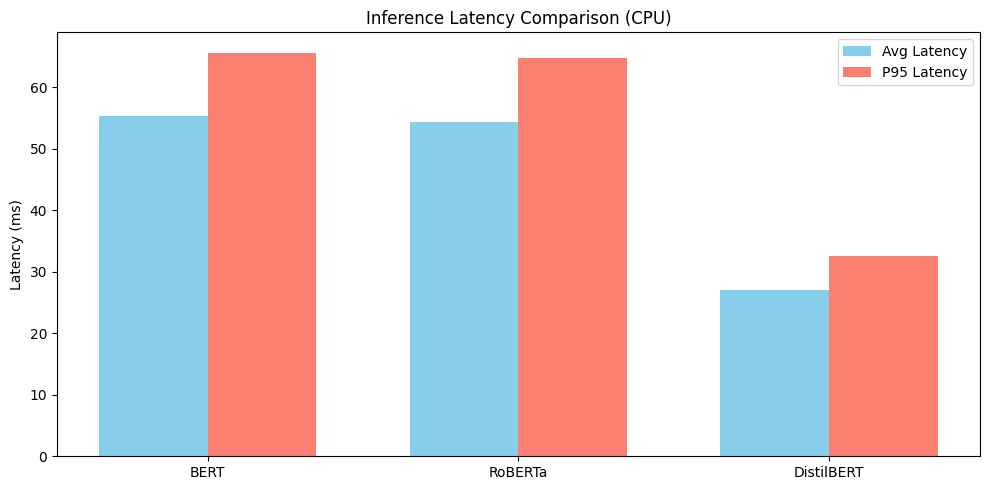


ACCURACY vs SPEED SUMMARY
Model              F1  Precision   Recall   Avg ms
-------------------------------------------------------
BERT           0.7151     0.7070   0.7388     55.3
RoBERTa        0.7143     0.6993   0.7323     54.3
DistilBERT     0.5867     0.8081   0.5531     27.1


In [14]:
models_dir = './models'
timing_models = {
    'BERT':       os.path.join(models_dir, 'bert'),
    'RoBERTa':    os.path.join(models_dir, 'roberta'),
    'DistilBERT': os.path.join(models_dir, 'distilbert'),
}

timing_samples = [
    'This is a great product! Highly recommend.',
    'You are so stupid and worthless!',
    'I hate people from that country.',
    'I am going to hurt you, watch your back.',
    "Let's grab coffee sometime!",
]

def run_inference(text, model, tokenizer, config):
    """
    Run inference menggunakan model yang sudah di-load di memori.
    """
    model.eval()

    preprocessor = TextPreprocessor()
    cleaned = preprocessor.clean_text(text)
    
    inputs = tokenizer(cleaned, return_tensors='pt', truncation=True, max_length=128, padding=True)

    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.sigmoid(logits).squeeze().tolist()

    scores = {config['reverse_schema'][str(i)]: round(p, 4) for i, p in enumerate(probs)}
    flagged = [label for label, score in scores.items() if score >= 0.5]
    risk_score = round(max(probs), 4)

    return {
        'is_flagged': len(flagged) > 0,
        'labels': flagged,
        'scores': scores,
        'risk_score': risk_score,
    }

N_RUNS = 10
timing_summary = {}

print('=' * 70)
print(f'INFERENCE TIMING ({N_RUNS} runs × {len(timing_samples)} samples per model)')
print('=' * 70)

for model_label, model_path in timing_models.items():
    print(f'\n{"=" * 70}')
    print(f' LOADING MODEL: {model_label}')
    print(f'{"=" * 70}')

    config = joblib.load(os.path.join(model_path, 'config.pkl'))
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    
    for text in timing_samples:
        result = run_inference(text, model, tokenizer, config)
        status = 'FLAGGED' if result['is_flagged'] else 'CLEAN'
        print(f'\n  [{status}] {text[:60]}')
        if result['is_flagged']:
            print(f'  Labels     : {result["labels"]}')
            print(f'  Risk score : {result["risk_score"]}')
        print('  Scores:')
        for label, score in result['scores'].items():
            bar = '█' * int(score * 20)
            print(f'    {label:<20} {score:.4f}  {bar}')

    print(f'\n  Benchmarking {model_label}...')
    times = []
    
    run_inference("warmup", model, tokenizer, config)

    for _ in range(N_RUNS):
        for text in timing_samples:
            t0 = time.perf_counter()
            run_inference(text, model, tokenizer, config)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000) # Convert to ms

    avg_ms = sum(times) / len(times)
    min_ms = min(times)
    max_ms = max(times)
    p95_ms = np.percentile(times, 95)

    timing_summary[model_label] = {
        'avg_ms': avg_ms,
        'min_ms': min_ms,
        'max_ms': max_ms,
        'p95_ms': p95_ms,
    }

    print(f'  Latency — avg: {avg_ms:.2f} ms | min: {min_ms:.2f} ms | max: {max_ms:.2f} ms | p95: {p95_ms:.2f} ms')

print('\n' + '=' * 70)
print(f'{"Model":<12} {"Avg (ms)":>10} {"Min (ms)":>10} {"Max (ms)":>10} {"P95 (ms)":>10}')
print('-' * 55)
for m, t in timing_summary.items():
    print(f'{m:<12} {t["avg_ms"]:>10.2f} {t["min_ms"]:>10.2f} {t["max_ms"]:>10.2f} {t["p95_ms"]:>10.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
models_t = list(timing_summary.keys())
avgs = [timing_summary[m]['avg_ms'] for m in models_t]
p95s = [timing_summary[m]['p95_ms'] for m in models_t]

x = np.arange(len(models_t))
width = 0.35

ax.bar(x - width/2, avgs, width, label='Avg Latency', color='skyblue')
ax.bar(x + width/2, p95s, width, label='P95 Latency', color='salmon')

ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency Comparison (CPU)')
ax.set_xticks(x)
ax.set_xticklabels(models_t)
ax.legend()

plt.tight_layout()
plt.savefig('./comparison_inference_latency.png')
plt.show()

print('\n' + '=' * 70)
print('ACCURACY vs SPEED SUMMARY')
print('=' * 70)
print(f'{"Model":<12} {"F1":>8} {"Precision":>10} {"Recall":>8} {"Avg ms":>8}')
print('-' * 55)
for m in ['BERT', 'RoBERTa', 'DistilBERT']:
    r = results[m]
    ms = timing_summary[m]['avg_ms']
    print(f'{m:<12} {r["f1"]:>8.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {ms:>8.1f}')

In [15]:
print('\n' + '='*70 + '\nTRAINING COMPLETE\n' + '='*70)
print(f'\nSaved models in: {models_dir}/')
for entry in sorted(os.listdir(models_dir)):
    print(f'  {entry}/')


TRAINING COMPLETE

Saved models in: ./models/
  bert/
  comparison_overall_metrics.png/
  comparison_per_label_heatmap.png/
  comparison_radar.png/
  comparison_results.json/
  comparison_training_history.png/
  distilbert/
  roberta/
